# Exercise 1

## Problem 1
In this problem we will loog at a very simple machine learning pipeline.
We will load a dataset, perform some exploratory data analysis, train some models, and evaluate their performance.

We will work with the California Housing dataset from https://github.com/ageron/handson-ml2/tree/master/datasets/housing.

Our goal is to predict the `median_house_value` by using the other predictors (i.e., columns) of the dataset.

### 1. Load housing dataset

Import the `numpy` library as `np`, `pandas` library as `pd`, and `matplotlib.pyplot` as `plt`.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load the housing dataset `housing.csv` using the `read_csv()` function from `pandas`. Name the dataframe `housing`.


In [41]:
housing = pd.read_csv('housing.csv')

### 2. Quick look at the data
The `housing` dataframe is an object of class `DataFrame`. This class has several methods that allow you to look and modify the data. 
Here, we try to understand the dataset by calling the methods `head()`, `info()`, and `describe()`.

* What is the difference between the three methods?
* What are the data types of the columns (i.e., quantitative or qualitative)?
* Are there missing values (e.g., NAs)?
* Count the number of rows and column in `housing`.

In [42]:
print(housing.head())
print(housing.info())
print(housing.describe())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data colum

### 3. Exploratory data analysis

We want to better understand the dataset at hand by performing some exploratory data analysis.

Import the `scatter_matrix` function from the `plotting` submodule of `pandas`.

In [43]:
from pandas.plotting import scatter_matrix


Call the `scatter_matrix` and `corr` function on the quantitative variables of the `housing` dataset.

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.071035      -0.079809   
housing_

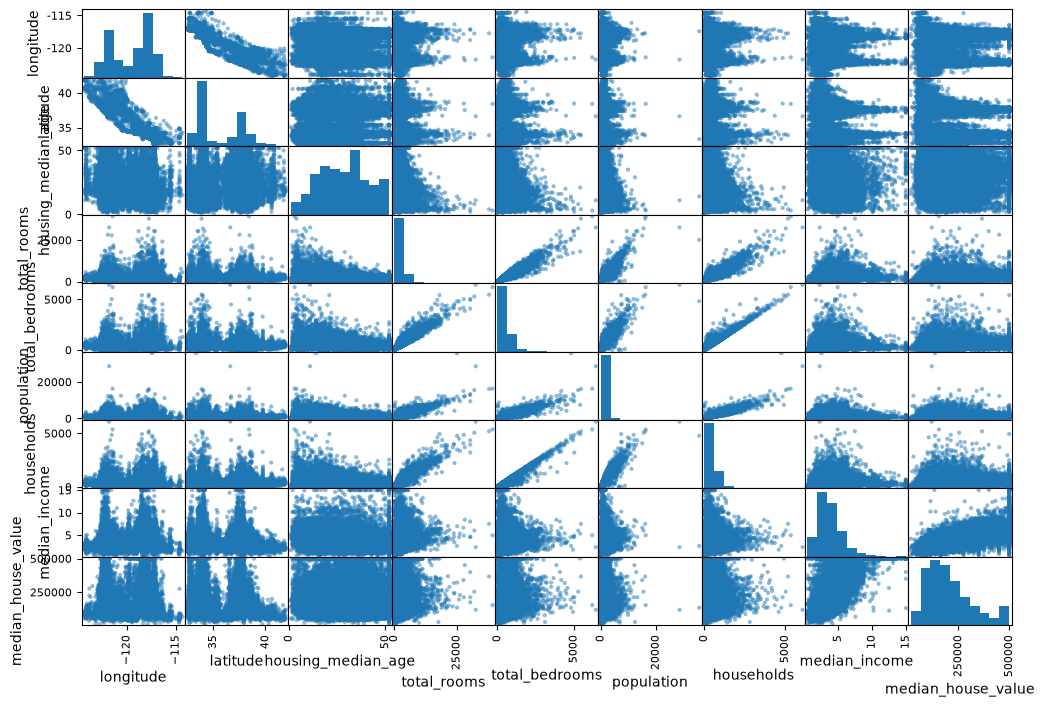

In [44]:
pd.plotting.scatter_matrix(housing.select_dtypes(include=[np.number]), figsize=(12, 8))
print(housing.select_dtypes(include=[np.number]).corr())

Can you explain the strong negative correlation between `latitude` and `longitude`?

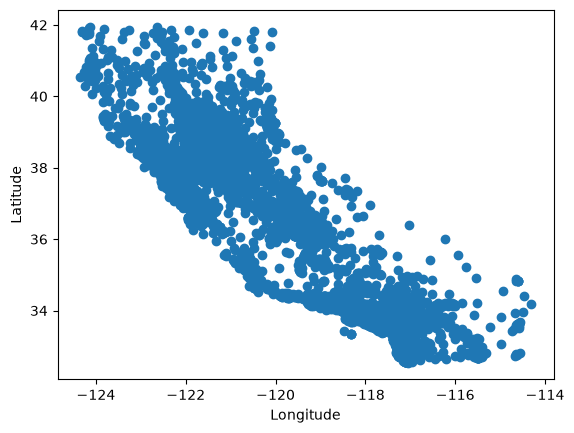

-0.92466443391504


In [45]:
#find coorelation betwwen latitude and longitude
plt.scatter(housing['longitude'], housing['latitude'])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
#get the actual number
print(housing['longitude'].corr(housing['latitude']))

Above we had to ignore the qualitative variable `ocean_proximity`. How could we analyze the relationship between `ocean_proximity` and the target variable `median_house_value`?

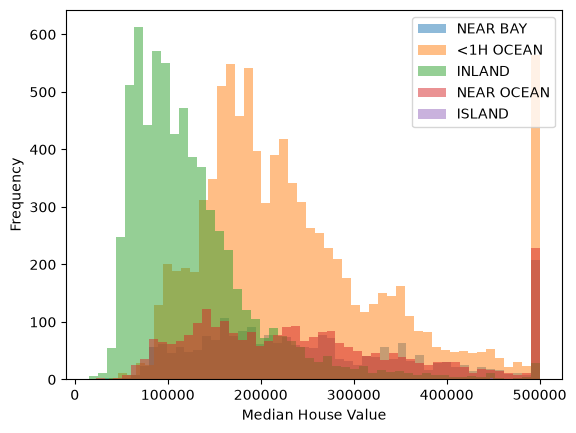

In [46]:

#Above we had to ignore the qualitative variable `ocean_proximity`. How could we analyze the relationship between `ocean_proximity` and the target variable `median_house_value`?
#lets do histogram of median_house_value for each category of ocean_proximity
for category in housing['ocean_proximity'].unique():
    plt.hist(housing[housing['ocean_proximity'] == category]['median_house_value'], bins=50, alpha=0.5, label=category)
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.legend()

#and a box plot



What is the most promising feature to predict `median_house_value`?

> 

Are there some features that are strongly correlated with each other?

> 

*Optional*: Some of the scatter plots (above and in the following) look more informative if you remove "outliers" using the following function.

In [47]:
def remove_outliers(data, lower_quantile=0.01, upper_quantile=0.99):
    """
    Remove outliers from each column in a quantitative (!) DataFrame based on quantile thresholds.
    Keeps only rows where all columns are within the specified quantile range.
    Returns a new DataFrame without outliers.
    """
    quantiles = data.quantile([lower_quantile, upper_quantile])
    df_filtered = data.apply(
        lambda col: col[(col >= quantiles.loc[lower_quantile, col.name]) & (col <= quantiles.loc[upper_quantile, col.name])]
    ).dropna()
    return df_filtered


### 4. Simple data transformations

Here, we perform some data transformations, such as data cleaning and feature engineering.

#### 4.1 Data cleaning

Let us start by removing any row containing NAs.

In [48]:

housing = housing.dropna()

#### 4.2 Feature engineering

Consider the columns `total_rooms` and `total_bedrooms`, which describe the total number of rooms and bedrooms in a district, and  `population` and `households`, which describe the population and the number of households in a district.
However, the total number of rooms in a district is not very informative if we don't know the number of households.
Similarly, the number of bedrooms might be more useful if we put it in relation to the total number of rooms.
Finally, one might be interested in the number of people per household, rather than the total population itself.

Based on the observations above, create three new features (i.e., columns) that can be more useful than the existing  `total_rooms`, `total_bedrooms`, `population`, and `households`.

In [50]:
# Based on the observations above, create three new features (i.e., columns) that can be more useful than the existing  `total_rooms`, `total_bedrooms`, `population`, and `households`.
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']
housing['bedrooms_per_room'] = housing['total_bedrooms'] / housing['total_rooms']
housing['population_per_household'] = housing['population'] / housing['households']


At this point, look at the scatter matrix of the newly created columns.

array([[<Axes: xlabel='rooms_per_household', ylabel='rooms_per_household'>,
        <Axes: xlabel='bedrooms_per_room', ylabel='rooms_per_household'>,
        <Axes: xlabel='population_per_household', ylabel='rooms_per_household'>,
        <Axes: xlabel='median_house_value', ylabel='rooms_per_household'>],
       [<Axes: xlabel='rooms_per_household', ylabel='bedrooms_per_room'>,
        <Axes: xlabel='bedrooms_per_room', ylabel='bedrooms_per_room'>,
        <Axes: xlabel='population_per_household', ylabel='bedrooms_per_room'>,
        <Axes: xlabel='median_house_value', ylabel='bedrooms_per_room'>],
       [<Axes: xlabel='rooms_per_household', ylabel='population_per_household'>,
        <Axes: xlabel='bedrooms_per_room', ylabel='population_per_household'>,
        <Axes: xlabel='population_per_household', ylabel='population_per_household'>,
        <Axes: xlabel='median_house_value', ylabel='population_per_household'>],
       [<Axes: xlabel='rooms_per_household', ylabel='median_house_v

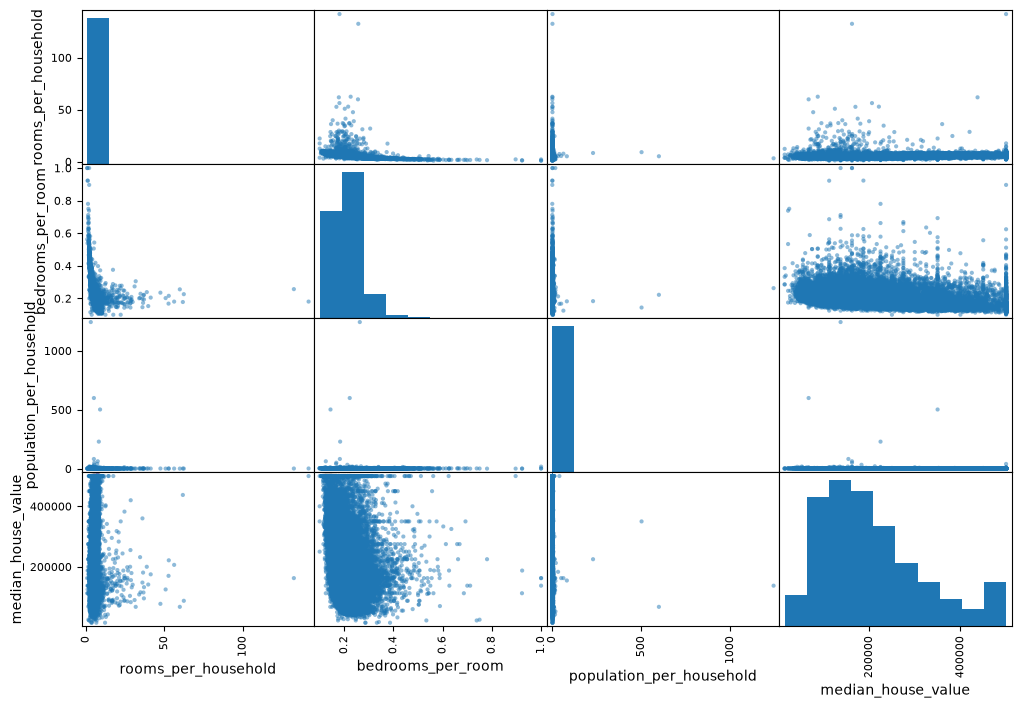

In [ ]:
#start by crateing a new DataFrame with the new features and the target variable
new_features = housing[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']]
#create a scatter matrix of the new features and the target variable
scatter_matrix(new_features.join(housing['median_house_value']), figsize=(12, 8))

                        

Compute the correlation among the new variables. Also, compute the correlation between  `total_rooms`, `total_bedrooms`, `population`, and `households`. What do you observe?

In [54]:
new_features.corr()

,rooms_per_household,bedrooms_per_room,population_per_household
rooms_per_household,1.000000,-0.416952,-0.004873
bedrooms_per_room,-0.416952,1.000000,0.002938
population_per_household,-0.004873,0.002938,1.000000


#### 4.3 Categorical variables

The column `ocean_proximity` is a qualitative variable with different categories. It is always good to convert qualitative variables into quantitative before fitting machine learning models. To do so, we will use the `OrdinalEncoder` function from the `preprocessing` package of the `sklearn` library.

Import the `OrdinalEncoder` class.

In [56]:
from sklearn.preprocessing import OrdinalEncoder


We first instantiate an object from class `OrdinalEncoder` and we call it `my_ordinal_encoder`.

In [ ]:
encoder = OrdinalEncoder()


Create a new column named `ocean_proximity_enc` by transforming the `ocean_proximity` column with the `my_ordinal_encoder.fit_transform` function.

_Hint_: Make sure you access the `ocean_proximity` column with the double bracket `[[` and not with the single bracket `[`.

In [ ]:
housing["ocean_proximity"] = encoder.fit_transform(housing[["ocean_proximity"]])

### 5. Prepare data for machine learning algorithms

Create a "clean" dataset, without the columns `total_rooms`, `total_bedrooms`, `population`, `households`, and `ocean_proximity`.
Split the new dataset into predictors `X` and response `y`. 

In [58]:
housing_clean = housing.drop(columns=["total_rooms", "total_bedrooms", "population",
                                      "households", "ocean_proximity"])

X = housing_clean.drop(columns="median_house_value")
y = housing_clean["median_house_value"]

If we fit and evaluate our model on the same data we obtain overly optimistic results. For this reason, we have to split the dataset into a train and test part.

*Note: See next week's slides for details on this concept*

Split the data by keeping 20% of the observations in the test set. Set the random seed to `42`.
(Replace the `??` below)

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

### 6. Fit simple models

We are now ready to fit our first two models, KNN and LinearRegression.

Let us first fit a KNN model with $k=8$.

In [61]:
from sklearn.neighbors import KNeighborsRegressor

In [62]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


Let us now fit a Linear Regression model.

In [63]:
from sklearn.linear_model import LinearRegression

In [64]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-42349.38,-40839.27, 985.56,..., 3963.15,385323.69, -354.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['longitude','latitude','housing_median_age',...,'rooms_per_household', 'bedrooms_per_room','population_per_household']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.702e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


### 7. Make predictions and evaluate models

We now want to make some predictions on test set, i.e., `X_test`, and to evaluate how well the models perform.

Predict the fitted models on the test set `X_test` and store the predictions in `knn_preds` and `lin_reg_preds`, respectively.

_Hint_: use the `<fitted_object>.predict` method.

In [65]:
knn_preds = knn.predict(X_test)
knn_preds

array([174820., 152320., 237800., ...,  97040., 168760., 113020.],
      shape=(4087,))

In [66]:
lin_reg_preds = lin_reg.predict(X_test)
lin_reg_preds

array([208574.98190041, 172954.87267882, 192931.64128822, ...,
       117504.23394422, 148512.39566311, 157068.36387088], shape=(4087,))

Evaluate the performance of the models using the root mean square error (RMSE). Fill the `??`.

In [67]:
from sklearn.metrics import root_mean_squared_error

In [68]:
root_mean_squared_error(y_test, knn.predict(X_test))

64161.47951500161

In [69]:
root_mean_squared_error(y_test, lin_reg.predict(X_test))

73442.50503076256

*Optional:* Can you also compute these errors without using any library function (i.e., by using only `numpy`)?

In [70]:
def RMSE(y_true, y_pred):
    return np.sqrt(sum((y_true - y_pred) ** 2) / len(y_true))
# call and compare to the noraml function
print("KNN RMSE:", RMSE(y_test, knn.predict(X_test)))
print("KNN RMSE (using sklearn):", root_mean_squared_error(y_test, knn.predict(X_test)))
print("Linear Regression RMSE:", RMSE(y_test, lin_reg.predict(X_test)))
print("Linear Regression RMSE (using sklearn):", root_mean_squared_error(y_test, lin_reg.predict(X_test)))


KNN RMSE: 64161.47951500161
KNN RMSE (using sklearn): 64161.47951500161
Linear Regression RMSE: 73442.50503076256
Linear Regression RMSE (using sklearn): 73442.50503076256


## Problem 2


In this problem, we show that the regression function $f^*(x) := \operatorname{E}[Y \mid X = x]$, $x \in \mathbb{R}^p$, is **optimal** in the sense that it minimizes the expected squared prediction error.

In particular, for a fixed predictor value $x \in \mathbb{R}^p$, show that

$$f^*(x) = 
\underset{f(x)}{\operatorname{arg min}} \operatorname{E}\left[\left(Y - f(x)\right)^2 \mid X = x\right].$$

### answer

Fix $x \in \mathbb{R}^p$ and write $c = f(x)$, which is just a constant once $x$ is fixed. Let $\mu = \mathrm{E}[Y \mid X = x] = f^*(x)$. We want to show that $c = \mu$ minimizes

$$
g(c) = \mathrm{E}\left[(Y - c)^2 \mid X = x\right].
$$

**Proof.** Adding and subtracting $\mu$:

$$
(Y - c)^2 = \big((Y - \mu) + (\mu - c)\big)^2 = (Y - \mu)^2 + 2(Y - \mu)(\mu - c) + (\mu - c)^2.
$$

Taking the conditional expectation given $X = x$, and using that $\mu - c$ is a constant given $X = x$:

$$
g(c) = \mathrm{E}\left[(Y - \mu)^2 \mid X = x\right] + 2(\mu - c)\,\mathrm{E}\left[Y - \mu \mid X = x\right] + (\mu - c)^2.
$$

The middle term vanishes, since

$$
\mathrm{E}[Y - \mu \mid X = x] = \mathrm{E}[Y \mid X = x] - \mu = \mu - \mu = 0.
$$

Hence

$$
g(c) = \underbrace{\mathrm{E}\left[(Y - \mu)^2 \mid X = x\right]}_{\text{does not depend on } c} + \underbrace{(\mu - c)^2}_{\geq 0}.
$$

The first term equals $\mathrm{Var}(Y \mid X = x)$ and does not depend on $c$. The second term is non-negative and equals zero if and only if $c = \mu$. Therefore $g(c)$ is uniquely minimized at

$$
c = \mu = \mathrm{E}[Y \mid X = x] = f^*(x),
$$

that is,

$$
f^*(x) = \underset{f(x)}{\operatorname{argmin}} \;